In [2]:
from __future__ import absolute_import, division, print_function
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.autograd import Variable
import numpy as np

In [9]:
# Chuẩn bị dữ liệu
from keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
# Chuyển đổi sang định dạng float32.
x_train, x_test = np.array(x_train, np.float32), np.array(x_test, np.float32)
# Chuẩn hóa ảnh từ from [0, 255] to [0, 1].
x_train, x_test = x_train / 255.0, x_test / 255.0
x_train, x_test, y_train, y_test = torch.from_numpy(x_train), torch.from_numpy(x_test), torch.from_numpy(y_train), torch.from_numpy(y_test)

In [10]:
# MNIST dataset parameters.
num_classes = 10 # total classes (0-9 digits).
num_features = 784 # data features (img shape: 28*28).
# Network parameters.
n_hidden_1 = 128 # 1st layer number of neurons.
# n_hidden_2 = 256 # 2nd layer number of neurons.


In [11]:
batch_size = 16


In [20]:
trainloader = []
for (i,j) in zip(x_train, y_train):
    trainloader.append([i,j])
trainloader = torch.utils.data.DataLoader(trainloader, shuffle=True, batch_size=batch_size)

testloader = []
for (i,j) in zip(x_test, y_test):
    testloader.append([i,j])
testloader = torch.utils.data.DataLoader(testloader, shuffle=True, batch_size=batch_size)


16


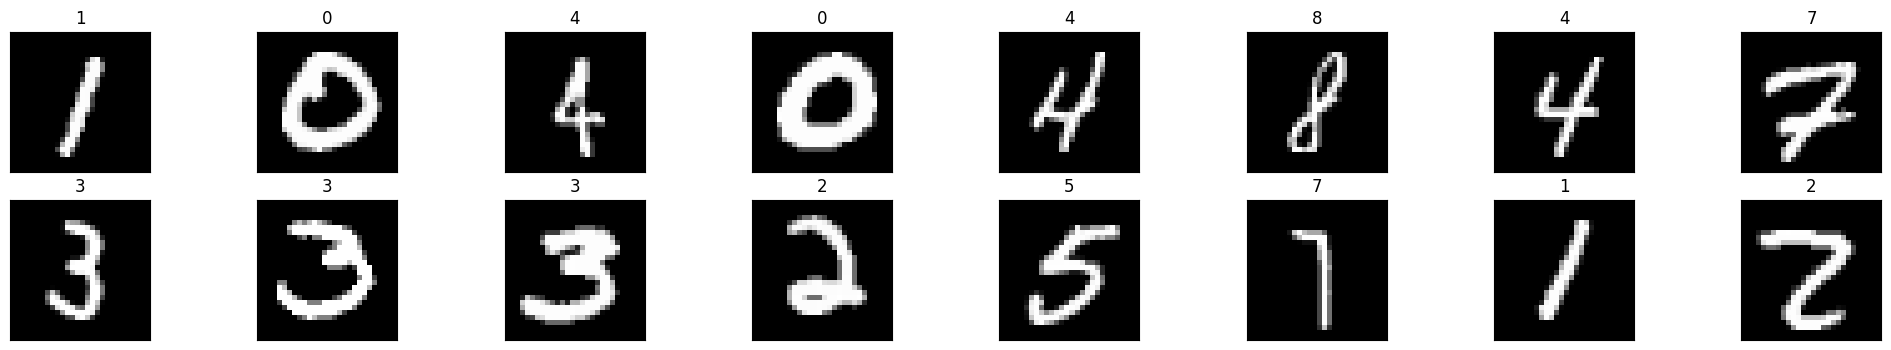

In [29]:
import matplotlib.pyplot as plt
%matplotlib inline
    
dataiter = iter(trainloader)
images, labels = dataiter.__next__()
images = images.numpy()

# hiển thị dữ liệu theo từng batch và nhãn tương ứng
fig = plt.figure(figsize=(25, 4))
print(batch_size)


for idx in np.arange(batch_size):
    ax = fig.add_subplot(2, int(batch_size/2), idx+1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(images[idx]), cmap='gray')
    ax.set_title(str(labels[idx].item()))

In [30]:
import torch.nn as nn
import torch.nn.functional as F

## định nghĩa mạng
class MLPModel(nn.Module):
    def __init__(self):
        super(MLPModel, self).__init__()
        self.fc1 = nn.Linear(num_features, n_hidden_1)
        # linear layer (n_hidden -> hidden_2)
        self.fc2 = nn.Linear(n_hidden_1, num_classes)

    def forward(self, x):
        # chuyển từ định dạng ma trận thành vector
        x = x.view(-1, 28 * 28)
        # add hidden layer, with relu activation function
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return x

# initialize the NN
model = MLPModel()
print(model)

MLPModel(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [31]:
import torch.optim as optim
# trong hàm loss cross entropy đã áp dụng hàm soft max cho vector đầu ra
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)


In [32]:
def accuracy():
    correct = 0
    total = 0
    # since we're not training, we don't need to calculate the gradients for our outputs
    with torch.no_grad():
        for data in testloader:
            images, labels = data
            # calculate outputs by running images through the network
            outputs = model(images)
            # the class with the highest energy is what we choose as prediction
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return correct/total

In [33]:
losses = []
for epoch in range(100):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
    losses.append(running_loss)
    if epoch % 10 == 9:
        print('Iteration: %d, accuracy: %.3f' %(epoch + 1, accuracy()))

print('Finished Training')

Iteration: 10, accuracy: 0.851
Iteration: 20, accuracy: 0.862
Iteration: 30, accuracy: 0.866
Iteration: 40, accuracy: 0.866
Iteration: 50, accuracy: 0.977
Iteration: 60, accuracy: 0.979
Iteration: 70, accuracy: 0.979
Iteration: 80, accuracy: 0.980
Iteration: 90, accuracy: 0.980
Iteration: 100, accuracy: 0.980
Finished Training


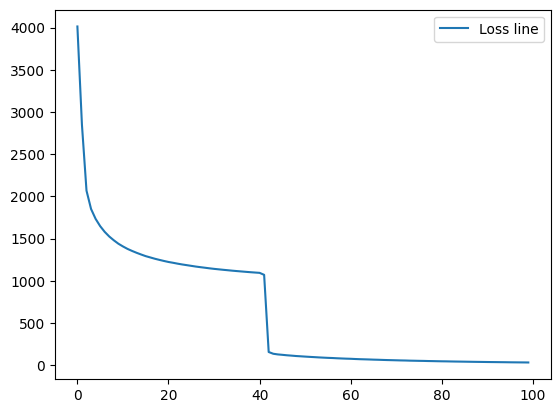

In [34]:
# Biểu đồ biểu diễn độ biến thiên của hàm mất mát qua các vòng lặp
plt.plot([i for i in range(len(losses))], losses, label='Loss line')
# plt.plot(X, np.array(W * X + b), label='Fitted line')
plt.legend()
plt.show()

In [39]:
import torch.nn as nn
import torch.nn.functional as F

class MLPModel(nn.Module):
    def __init__(self, layer_sizes):
        """
        layer_sizes: list các kích thước lớp
        Ví dụ: [784, 128, 64, 10] tạo mạng:
        Input(784) → Hidden1(128) → Hidden2(64) → Output(10)
        """
        super(MLPModel, self).__init__()
        self.layers = nn.ModuleList()
        
        # Tạo các linear layer
        for i in range(len(layer_sizes) - 1):
            self.layers.append(nn.Linear(layer_sizes[i], layer_sizes[i+1]))
    
    def forward(self, x):
        # Flatten ảnh
        x = x.view(x.size(0), -1)
        
        # Đi qua các lớp ẩn với ReLU
        for layer in self.layers[:-1]:
            x = F.relu(layer(x))
        
        # Output layer (không có activation)
        x = self.layers[-1](x)
        return x


# # 2 tầng ẩn:
# model = MLPModel([784, 128, 64, 10])
# 3 tầng ẩn:
model_3 = MLPModel([784, 256, 128, 64, 10])
# 5 tầng ẩn:
model_5 = MLPModel([784, 256, 128, 64, 32, 10])

learning_rate = [0.1, 0.05, 0.001]

x_train.shape,x_test.shape,y_train.shape,y_test.shape


(torch.Size([60000, 28, 28]),
 torch.Size([10000, 28, 28]),
 torch.Size([60000]),
 torch.Size([10000]))

In [41]:
# tunning learning rate for each model

for lr in learning_rate:
    print(f"Learning rate: {lr}")
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model_3.parameters(), lr = lr)

    losses = []
    for epoch in range(20):  # loop over the dataset multiple times

        running_loss = 0.0
        for i, data in enumerate(trainloader, 0):
            # get the inputs; data is a list of [inputs, labels]
            inputs, labels = data

            # zero the parameter gradients
            optimizer.zero_grad()

            # forward + backward + optimize
            outputs = model_3(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # print statistics
            running_loss += loss.item()
        losses.append(running_loss)
        if epoch % 10 == 9:
            print('Iteration: %d, accuracy: %.3f' %(epoch + 1, accuracy()))

    print('Finished Training')


Learning rate: 0.1
Iteration: 10, accuracy: 0.939
Iteration: 20, accuracy: 0.939
Finished Training
Learning rate: 0.05
Iteration: 10, accuracy: 0.939
Iteration: 20, accuracy: 0.939
Finished Training
Learning rate: 0.001
Iteration: 10, accuracy: 0.939
Iteration: 20, accuracy: 0.939
Finished Training


In [ ]:
# tunning learning rate for each model

for lr in learning_rate:
    print(f"Learning rate: {lr}")
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model_5.parameters(), lr = lr)

    losses = []
    for epoch in range(100):  # loop over the dataset multiple times

        running_loss = 0.0
        for i, data in enumerate(trainloader, 0):
            # get the inputs; data is a list of [inputs, labels]
            inputs, labels = data

            # zero the parameter gradients
            optimizer.zero_grad()

            # forward + backward + optimize
            outputs = model_5(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # print statistics
            running_loss += loss.item()
        losses.append(running_loss)
        if epoch % 10 == 9:
            print('Iteration: %d, accuracy: %.3f' %(epoch + 1, accuracy()))

    print('Finished Training')


Learning rate: 0.1
Iteration: 10, accuracy: 0.939
Iteration: 20, accuracy: 0.939
Iteration: 30, accuracy: 0.939
Iteration: 40, accuracy: 0.939
Iteration: 50, accuracy: 0.939
Iteration: 60, accuracy: 0.939
Iteration: 70, accuracy: 0.939
Iteration: 80, accuracy: 0.939
Iteration: 90, accuracy: 0.939
Iteration: 100, accuracy: 0.939
Finished Training
Learning rate: 0.05
Iteration: 10, accuracy: 0.939
Iteration: 20, accuracy: 0.939
Iteration: 30, accuracy: 0.939
Iteration: 40, accuracy: 0.939
Iteration: 50, accuracy: 0.939
Iteration: 60, accuracy: 0.939
Iteration: 70, accuracy: 0.939
Iteration: 80, accuracy: 0.939
Iteration: 90, accuracy: 0.939
Iteration: 100, accuracy: 0.939
Finished Training
Learning rate: 0.001
Iteration: 10, accuracy: 0.939
Iteration: 20, accuracy: 0.939
Iteration: 30, accuracy: 0.939
Iteration: 40, accuracy: 0.939
Iteration: 50, accuracy: 0.939
Iteration: 60, accuracy: 0.939
Iteration: 70, accuracy: 0.939
Iteration: 80, accuracy: 0.939
